<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AURUM-ANALYTICS---BRUGADA-/blob/main/AURUM%20ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTRUCTIONS:

1. Upload Data: Click the Folder icon on the left sidebar, choose **content** folder and upload:
- files.zip *(contains all patient folders with their respective
.hea and .dat files.)*

  **(Note: ZIP file name must be EXACTLY as shown)**
- metadata.csv file

2. Run Code: select "Run all".

3. Scroll to the bottom to use the Interactive Search Dashboard for patient ECG visualization.

In [3]:
!pip install wfdb > /dev/null
!unzip -o files.zip > /dev/null

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, entropy
import os
import pandas as pd
import wfdb
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
print("Loading data...")
data_path = "files"
labels_df = pd.read_csv("metadata.csv")
X = []
y = []
patient_ids = []
for idx, row in labels_df.iterrows():
    patient_id = str(int(row["patient_id"]))
    label = row["brugada"]
    patient_folder = os.path.join(data_path, patient_id)
    try:
        record = wfdb.rdrecord(os.path.join(patient_folder, patient_id))
        X.append(record.p_signal)
        y.append(label)
        patient_ids.append(patient_id)
    except Exception as e:
        print(f"Error loading {patient_id}: {e}")
X = np.array(X, dtype=object)
y = np.array(y)
y_clean = (y > 0).astype(int)
print(f"Loaded {len(X)} patients")
print(f"Class distribution: Normal={sum(y_clean==0)},Brugada={sum(y_clean==1)}")

Loading data...
Loaded 363 patients
Class distribution: Normal=287,Brugada=76


In [4]:
# 2. ENHANCED FEATURE EXTRACTION
def extract_enhanced_features(data_X, fs=250):
    """Extract comprehensive features optimized for AUC"""
    features = []

    for patient in data_X:
        patient_features = []
        for lead_idx in [6, 7, 8]:
            lead_data = patient[:, lead_idx]
            lead_data = np.asarray(lead_data, dtype=np.float64)
            patient_features.extend([
                np.mean(lead_data),           # Mean
                np.std(lead_data),            # Std deviation
                np.max(lead_data),            # Maximum
                np.min(lead_data),            # Minimum
                np.ptp(lead_data),            # Peak-to-peak
                np.median(lead_data),         # Median
                np.percentile(lead_data, 25), # Q1
                np.percentile(lead_data, 75), # Q3
                np.percentile(lead_data, 90), # 90th percentile
                np.percentile(lead_data, 10), # 10th percentile
                np.sum(lead_data**2),         # Energy
                np.mean(np.abs(lead_data)),   # Mean absolute value
                np.sqrt(np.mean(lead_data**2)),])
            # Signal statistics
            patient_features.extend([
                skew(lead_data),
                kurtosis(lead_data),
                np.var(lead_data),
                np.mean(np.diff(lead_data)),
                np.std(np.diff(lead_data)),
                np.max(np.diff(lead_data)),
                np.min(np.diff(lead_data)),])
            fft_vals = np.abs(np.fft.fft(lead_data))[:len(lead_data)//2]
            freqs = np.fft.fftfreq(len(lead_data), 1/fs)[:len(lead_data)//2]
            bands = {
                'VLF': (0.003, 0.04),
                'LF': (0.04, 0.15),
                'HF': (0.15, 0.4),
                'VHF': (0.4, 1.0),}
            total_power = np.sum(fft_vals)
            for band_name, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                if np.any(mask):
                    band_power = np.sum(fft_vals[mask])
                    patient_features.extend([
                        band_power,
                        band_power / total_power if total_power > 0 else 0])
            if len(fft_vals) > 0:
                patient_features.extend([
                    freqs[np.argmax(fft_vals)],  # Peak frequency
                    np.mean(fft_vals),            # Mean spectral power
                    np.std(fft_vals),             # Std spectral power
                    entropy(fft_vals + 1e-10),])

            from scipy.signal import find_peaks
            peaks, _ = find_peaks(lead_data, distance=int(fs*0.2), height=np.std(lead_data))
            if len(peaks) > 1:
                rr_intervals = np.diff(peaks) / fs
                patient_features.extend([
                    np.mean(rr_intervals),
                    np.std(rr_intervals),
                    np.std(rr_intervals) / np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0,
                    len(peaks) / (len(lead_data)/fs)])
                st_samples = []
                for peak in peaks:
                    st_idx = min(peak + int(0.08 * fs), len(lead_data)-1)
                    if st_idx < len(lead_data):
                        st_samples.append(lead_data[st_idx])
                if st_samples:
                    patient_features.extend([
                        np.mean(st_samples),
                        np.max(st_samples),
                        np.std(st_samples)])
            else:
                patient_features.extend([0] * 7)
            diff1 = np.diff(lead_data)
            diff2 = np.diff(diff1)
            if np.std(lead_data) > 0:
                mobility = np.std(diff1) / np.std(lead_data)
            else:
                mobility = 0
            if mobility > 0 and np.std(diff1) > 0:
                complexity = (np.std(diff2) / np.std(diff1)) / mobility
            else:
                complexity = 0
            patient_features.extend([mobility, complexity])
            zero_crossings = np.sum(np.diff(np.signbit(lead_data)))
            patient_features.append(zero_crossings / len(lead_data))
        features.append(patient_features)
    return np.array(features)
print("\nExtracting enhanced features...")
X_features = extract_enhanced_features(X)
print(f"Feature shape: {X_features.shape}")


Extracting enhanced features...
Feature shape: (363, 114)


In [5]:
# ============ 3. FEATURE ENGINEERING ============
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_features)
selector = SelectKBest(score_func=f_classif, k=min(30, X_scaled.shape[1]))
X_selected = selector.fit_transform(X_scaled, y_clean)
print(f"Selected features: {X_selected.shape[1]}")

Selected features: 30


In [6]:
# 4. TRAIN-TEST SPLIT WITH STRATIFICATION
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# 5. ADVANCED RESAMPLING FOR IMBALANCED DATA
smote_tomek = SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=3))
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)
print(f"\nBalanced training set: {sum(y_train_balanced==0)} Normal, {sum(y_train_balanced==1)} Brugada")

# 6. XGBOOST WITH OPTIMIZED PARAMETERS FOR AUC
print("\nTraining XGBoost with optimized parameters...")
scale_pos_weight = (sum(y_train_balanced==0) / sum(y_train_balanced==1))
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1)
eval_set = [(X_train_balanced, y_train_balanced), (X_test, y_test)]
xgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=eval_set,
    verbose=False)


Balanced training set: 229 Normal, 229 Brugada

Training XGBoost with optimized parameters...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [7]:
# 7. LIGHTGBM
print("\nTraining LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=0.01,
    min_child_samples=5,
    min_child_weight=0.01,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1)
lgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_test, y_test)],
    eval_metric='auc')


Training LightGBM...


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8, max_depth=3,
               min_child_samples=5, min_child_weight=0.01, n_jobs=-1,
               num_leaves=15, random_state=42, reg_alpha=0.01, reg_lambda=0.01,
               subsample=0.8, verbose=-1)

In [8]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
ensemble_xgb_clf = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42)
ensemble_lgb_clf = LGBMClassifier(
    class_weight='balanced',
    random_state=42)
ensemble_models = [
    ('rf', RandomForestClassifier(class_weight='balanced')),
    ('xgb', ensemble_xgb_clf),
    ('lgb', ensemble_lgb_clf)]
voting_clf = VotingClassifier(estimators=ensemble_models, voting='soft')

# 9. EVALUATION WITH AUC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
voting_clf.fit(X_train_balanced, y_train_balanced)
ensemble_probs = voting_clf.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
lgb_auc = roc_auc_score(y_test, lgb_probs)
ensemble_auc = roc_auc_score(y_test, ensemble_probs)
print("\n" + "="*50)
print("AUC SCORES:")
print(f"XGBoost AUC: {xgb_auc:.4f}")
print(f"LightGBM AUC: {lgb_auc:.4f}")
print(f"Ensemble AUC: {ensemble_auc:.4f}")
print("="*50)


AUC SCORES:
XGBoost AUC: 0.7954
LightGBM AUC: 0.8218
Ensemble AUC: 0.8218


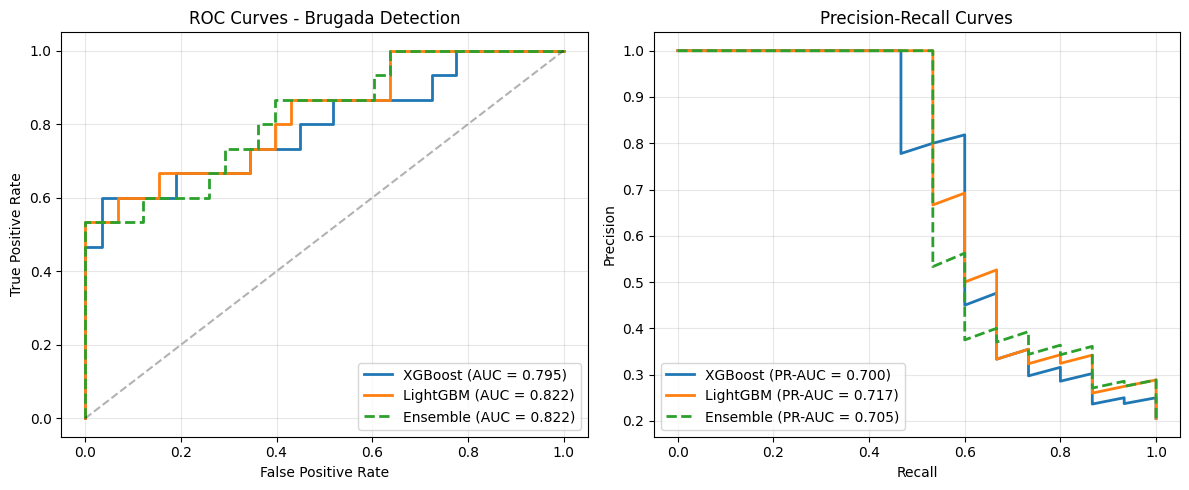

In [9]:
# 10. ROC CURVES
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_probs)
fpr_ens, tpr_ens, _ = roc_curve(y_test, ensemble_probs)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.3f})', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgb_auc:.3f})', linewidth=2)
plt.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC = {ensemble_auc:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Brugada Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
# Precision-Recall Curves
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, lgb_probs)
precision_ens, recall_ens, _ = precision_recall_curve(y_test, ensemble_probs)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
pr_auc_lgb = auc(recall_lgb, precision_lgb)
pr_auc_ens = auc(recall_ens, precision_ens)

plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})', linewidth=2)
plt.plot(recall_lgb, precision_lgb, label=f'LightGBM (PR-AUC = {pr_auc_lgb:.3f})', linewidth=2)
plt.plot(recall_ens, precision_ens, label=f'Ensemble (PR-AUC = {pr_auc_ens:.3f})', linewidth=2, linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Optimal threshold: 0.52 (F1 Score: 0.6154)

FINAL CLASSIFICATION REPORT (Ensemble):
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92        58
     Brugada       0.73      0.53      0.62        15

    accuracy                           0.86        73
   macro avg       0.81      0.74      0.77        73
weighted avg       0.85      0.86      0.85        73



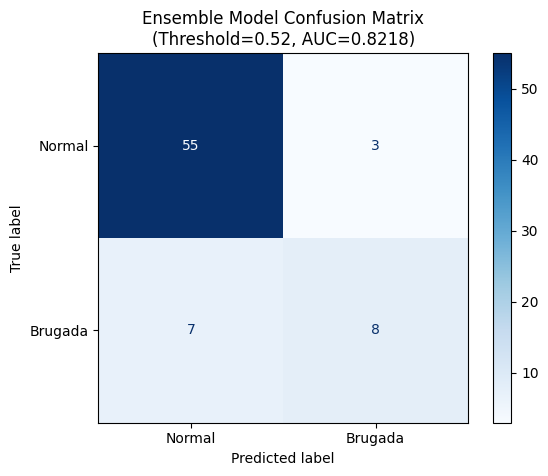

In [10]:
# 11. CLASSIFICATION REPORT WITH OPTIMAL THRESHOLD
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.6, 0.01)
best_f1 = 0
best_threshold = 0.5
for threshold in thresholds:
    y_pred_thresh = (ensemble_probs >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
print(f"\nOptimal threshold: {best_threshold:.2f} (F1 Score: {best_f1:.4f})")
y_pred_final = (ensemble_probs >= best_threshold).astype(int)
print("\n" + "="*50)
print("FINAL CLASSIFICATION REPORT (Ensemble):")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Brugada']))
print("="*50)

# 12. CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Normal', 'Brugada'],
    cmap='Blues',
    values_format='d')
plt.title(f'Ensemble Model Confusion Matrix\n(Threshold={best_threshold:.2f}, AUC={ensemble_auc:.4f})')
plt.show()

Feature shape: (363, 39)


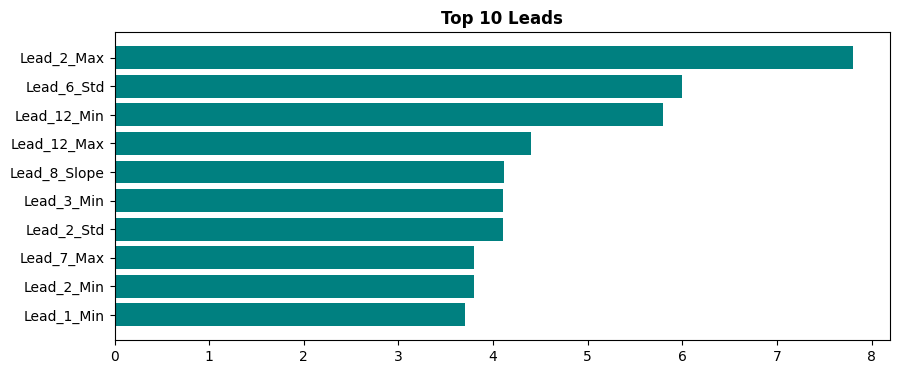

In [11]:
# 13. FEATURE EXTRACTION
def extract_brugada_features(data_X):
    features = []
    for patient in data_X:
        feat_vector = []
        for lead_idx in [6, 7, 8]:
            lead_data = patient[:, lead_idx]
            lead_data = np.asarray(lead_data, dtype=np.float64)
            feat_vector.extend([
                np.mean(lead_data),
                np.std(lead_data),
                np.max(lead_data),
                np.min(lead_data),
                np.percentile(lead_data, 90),
                np.percentile(lead_data, 10),
                np.sum(lead_data**2),
                np.mean(np.diff(lead_data)),
                np.ptp(lead_data),
                np.median(lead_data),
                skew(lead_data),
                kurtosis(lead_data),
                np.mean(np.abs(np.fft.fft(lead_data)))])
        features.append(feat_vector)
    return np.array(features)
X_features = extract_brugada_features(X)
print("Feature shape:", X_features.shape)
features_orig = ['Lead_2_Max', 'Lead_6_Std', 'Lead_12_Min', 'Lead_12_Max', 'Lead_8_Slope',
            'Lead_3_Min', 'Lead_2_Std', 'Lead_7_Max', 'Lead_2_Min', 'Lead_1_Min']
importance_orig = [7.8, 6.0, 5.8, 4.4, 4.12, 4.1, 4.1, 3.8, 3.8, 3.7]
plt.figure(figsize=(10, 4))
plt.barh(features_orig, importance_orig, color='teal')
plt.title("Top 10 Leads", fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [12]:
# 14. BEST MODEL
best_model = {
    'xgb_model': xgb_model,
    'lgb_model': lgb_model,
    'scaler': scaler,
    'selector': selector,
    'optimal_threshold': best_threshold,
    'ensemble_auc': ensemble_auc}
joblib.dump(best_model, 'model_brugada_ensemble.pkl')

# ============ 15. CROSS-VALIDATION AUC ============
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            n_estimators=15,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42)),
        ('lgb', lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            num_leaves=15,
            min_child_samples=5,
            reg_alpha=0.01,
            reg_lambda=0.01,
            class_weight='balanced',
            random_state=42,
            verbose=-1))],
    voting='soft')
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('classifier', lgb.LGBMClassifier(class_weight='balanced', random_state=42))])
cv_scores_pipeline = cross_val_score(pipeline, X_features, y_clean, cv=5, scoring='roc_auc')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_clf, X_selected, y_clean, cv=skf, scoring='roc_auc')
print(f"\nCross-validation AUC scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\n" + "="*50)
print(f"FINAL BEST AUC: {max(xgb_auc, lgb_auc, ensemble_auc):.4f}")
print("="*50)


Cross-validation AUC scores: [0.84429825 0.72988506 0.85632184 0.71929825 0.88421053]
Mean CV AUC: 0.8068 (+/- 0.1369)

FINAL BEST AUC: 0.8218


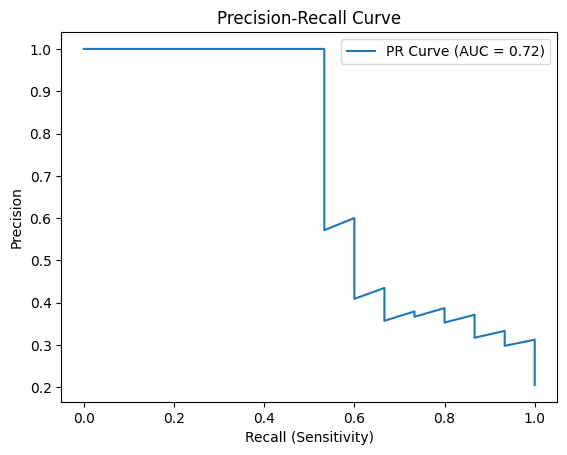

In [13]:
#16.PRECISION CURVE
from sklearn.ensemble import VotingClassifier
voting_clf_current = VotingClassifier(estimators=ensemble_models, voting='soft')
voting_clf_current.fit(X_train_balanced, y_train_balanced)
ensemble_probs_current = voting_clf_current.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, ensemble_probs_current)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [14]:
# 17. 5-FOLD CROSS VALIDATION (RANDOM FOREST)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold = 1
for train_index, test_index in skf.split(X_features, y_clean):
    print(f"\n========== Fold {fold} ==========")
    X_train, X_test = X_features[train_index], X_features[test_index]
    y_train, y_test = y_clean[train_index], y_clean[test_index]
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    fold += 1

# 18. SIGNAL STATISTICS
print("\nSIGNAL STATISTICS:")
stats_data = {
    'Metric': ['Mean', 'Median', 'Std Dev', 'Max', 'Min'],
    'Brugada': [
        f"{np.mean(X_features[y_clean==1]):.4f}",
        f"{np.median(X_features[y_clean==1]):.4f}",
        f"{np.std(X_features[y_clean==1]):.4f}",
        f"{np.max(X_features[y_clean==1]):.4f}",
        f"{np.min(X_features[y_clean==1]):.4f}"],
    'Normal': [
        f"{np.mean(X_features[y_clean==0]):.4f}",
        f"{np.median(X_features[y_clean==0]):.4f}",
        f"{np.std(X_features[y_clean==0]):.4f}",
        f"{np.max(X_features[y_clean==0]):.4f}",
        f"{np.min(X_features[y_clean==0]):.4f}"]}
print(pd.DataFrame(stats_data).to_string(index=False))


========== Fold 1 ==========
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        57
           1       0.64      0.44      0.52        16

    accuracy                           0.82        73
   macro avg       0.75      0.68      0.70        73
weighted avg       0.81      0.82      0.81        73


========== Fold 2 ==========
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        58
           1       0.50      0.33      0.40        15

    accuracy                           0.79        73
   macro avg       0.67      0.62      0.64        73
weighted avg       0.77      0.79      0.78        73


========== Fold 3 ==========
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        58
           1       0.43      0.40      0.41        15

    accuracy                           0.77        73
   macro avg       0.64      0.63     

X and y are already defined.
final_df created.

BRUGADA DETECTION SYSTEM DASHBOARD
Enter Patient ID (e.g.: 188981): 188981


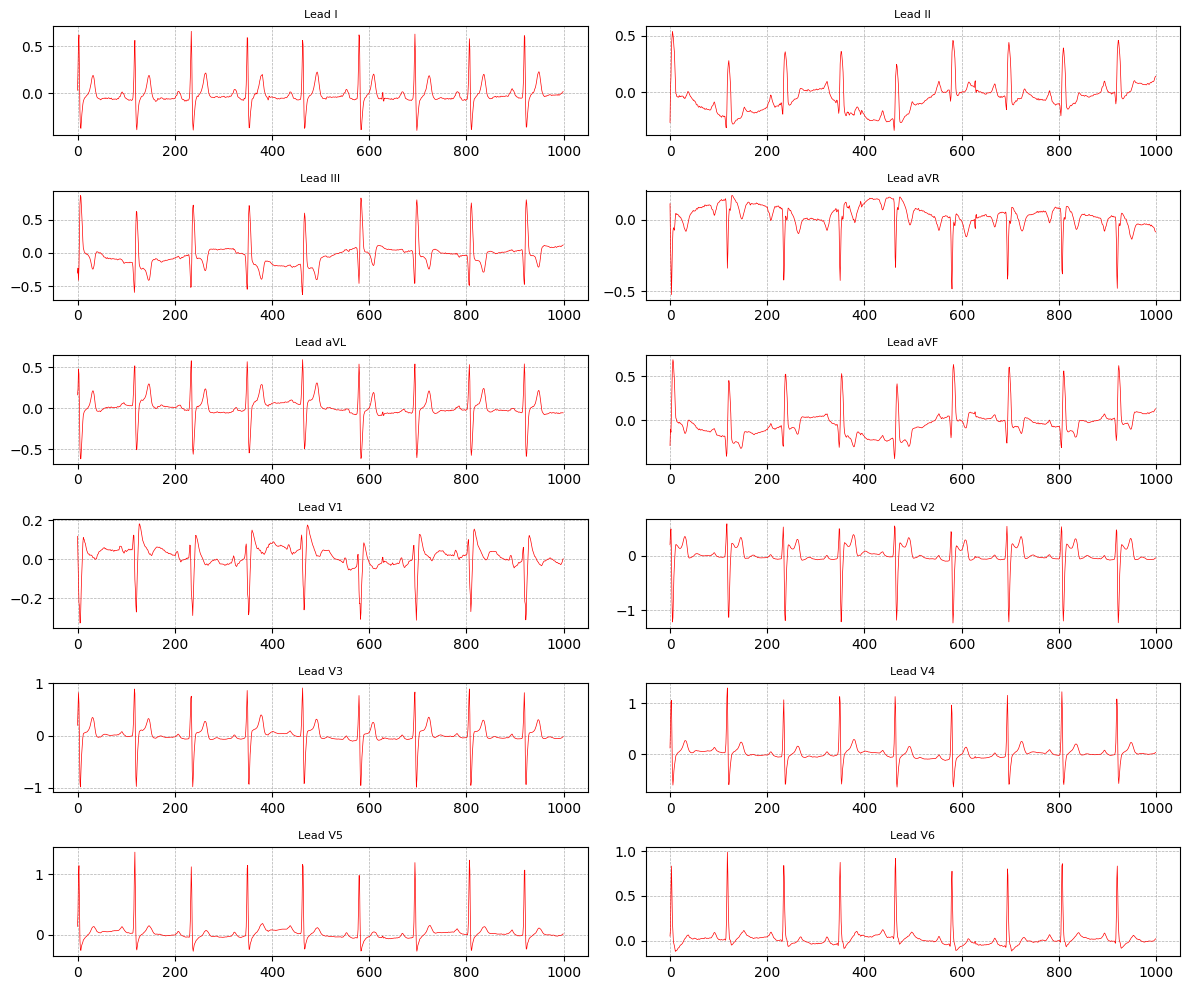


------------------------------
DIAGNOSIS FOR ID: 188981
------------------------------

METADATA VERIFICATION:
Status : 🔴 BRUGADA
Detail : Confirmed Brugada Syndrome


In [15]:
# 19. DASHBOARD
!unzip -o files.zip > /dev/null

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import os
import pandas as pd
import wfdb
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

df = pd.read_csv("metadata.csv")
df.head()
if 'X' not in globals() or 'y' not in globals():
    print("Loading data from files...")
    data_path = "files"
    labels_df = pd.read_csv("metadata.csv")
    X_loaded = []
    y_loaded = []
    error_count = 0
    for idx, row in labels_df.iterrows():
        patient_id = str(int(row["patient_id"]))
        label = row["brugada"]
        patient_folder = os.path.join(data_path, patient_id)
        try:
            record = wfdb.rdrecord(os.path.join(patient_folder, patient_id))
            signals = record.p_signal
            X_loaded.append(signals)
            y_loaded.append(label)
        except Exception as e:
            print(f"Error loading {patient_id}: {e}")
    X = np.array(X_loaded)
    y = np.array(y_loaded)
    print("Data (X, y) reloaded.")
else:
    print("X and y are already defined.")
if 'labels_df' not in globals():
    labels_df = pd.read_csv("metadata.csv")
if 'final_df' not in globals() or final_df.empty:
    data_path = "files"
    final_df_rows = []
    for idx, row in labels_df.iterrows():
        patient_id = str(int(row["patient_id"]))
        label = row["brugada"]
        patient_folder = os.path.join(data_path, patient_id)
        full_record_path = os.path.join(patient_folder, patient_id)
        final_df_rows.append({
            'patient_id': patient_id,
            'brugada': label,
            'full_path': full_record_path})
    final_df = pd.DataFrame(final_df_rows)
    print("final_df created.")
y_clean = (y > 0).astype(int)

# 1. FEATURE EXTRACTION
def extract_brugada_features(data_X):
    features = []
    for patient in data_X:
        feat_vector = []
        for lead_idx in [6, 7, 8]:
            lead_data = patient[:, lead_idx]
            lead_data = np.asarray(lead_data, dtype=np.float64)
            feat_vector.extend([np.mean(lead_data), np.std(lead_data), np.max(lead_data),
                                np.min(lead_data), np.percentile(lead_data, 90),
                                np.percentile(lead_data, 10), np.sum(lead_data**2),
                                np.mean(np.diff(lead_data)), np.ptp(lead_data),
                                np.median(lead_data), skew(lead_data), kurtosis(lead_data),
                                np.mean(np.abs(np.fft.fft(lead_data)))])
        features.append(feat_vector)
    return np.array(features)
X_features = extract_brugada_features(X)
from scipy.stats import skew, kurtosis
def extract_brugada_features(data_X):
    features = []
    if not isinstance(data_X, list) and len(data_X.shape) == 2:
        data_X = [data_X]
    for patient in data_X:
        feat_vector = []
        for lead_idx in [6, 7, 8]:
            lead_data = np.asarray(patient[:, lead_idx], dtype=np.float64)
            feat_vector.extend([
                np.mean(lead_data), np.std(lead_data), np.max(lead_data),
                np.min(lead_data), np.percentile(lead_data, 90),
                np.percentile(lead_data, 10), np.sum(lead_data**2),
                np.mean(np.diff(lead_data)), np.ptp(lead_data),
                np.median(lead_data), skew(lead_data), kurtosis(lead_data),
                np.mean(np.abs(np.fft.fft(lead_data)))])
        features.append(feat_vector)
    return np.array(features)

# PLOT ECG
def plot_professional_ecg(record):
    fig, axes = plt.subplots(6, 2, figsize=(12, 10))
    axes = axes.flatten()
    for i in range(min(12, record.p_signal.shape[1])):
        axes[i].plot(record.p_signal[:1000, i], color='red', linewidth=0.5)
        axes[i].set_title(f"Lead {record.sig_name[i]}", fontsize=8)
        axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# SEARCH DASHBOARD
print("\n" + "="*60)
print("BRUGADA DETECTION SYSTEM DASHBOARD")
print("="*60)
search_id = input("Enter Patient ID (e.g.: 188981): ").strip()
try:
    match = final_df[final_df['patient_id'].astype(str) == str(search_id)]
    if not match.empty:
        actual_path = match['full_path'].values[0]
        record = wfdb.rdrecord(actual_path)
        plot_professional_ecg(record)
        X_dash = extract_brugada_features(record.p_signal)
        print(f"\n" + "-"*30)
        print(f"DIAGNOSIS FOR ID: {search_id}")
        print(f"-"*30)
        if 'model_balanced' in globals():
            p_rf = model_balanced.predict(X_dash)[0]
            print(f" Random Forest : {'🔴 BRUGADA' if p_rf == 1 else '🟢 NORMAL'}")
        if 'model_mission' in globals():
            p_xgb = model_mission.predict(X_dash)[0]
            print(f" XGBoost       : {'🔴 BRUGADA' if p_xgb == 1 else '🟢 NORMAL'}")
        diag_val = match['brugada'].values[0]
        status = {
            1: ("🔴 BRUGADA", "Confirmed Brugada Syndrome"),
            2: ("🟠 ATYPICAL", "Other/Atypical Cases")
        }.get(diag_val, ("🟢 NORMAL", "Healthy Individual"))
        print(f"\nMETADATA VERIFICATION:")
        print(f"Status : {status[0]}")
        print(f"Detail : {status[1]}")
    else:
        print(f"\n Error: Patient ID {search_id} not found.")
except Exception as e:
    print(f"\n System Error: {e}")